# Representación vectorial y TF-IDF

> Cómo convertir documentos en vectores de longitud fija para compararlos o usarlos en un modelo: bolsa de palabras, ponderación TF-IDF calculada a mano y con scikit-learn, el efecto de `min_df`, `max_df` y los n-gramas en el vocabulario, y la similitud del coseno para buscar reseñas parecidas, sobre reseñas de Yelp. Con los errores típicos: ajustar el vectorizador antes de separar entrenamiento y prueba, convertir la matriz dispersa en densa y quitar las negaciones con las palabras vacías.
>
> **Requisitos previos:** [Preprocesamiento de texto](01-preprocesamiento-de-texto.ipynb) · **Relacionado:** [N-gramas y colocaciones](02-n-gramas-y-colocaciones.ipynb) · [Embeddings de palabras](04-embeddings-de-palabras.ipynb) · [Clasificación de texto](06-clasificacion-de-texto.ipynb)

## 1. Idea clave

Los modelos de aprendizaje automático y las medidas de distancia necesitan **vectores de longitud fija**, y los textos tienen longitudes distintas. La **bolsa de palabras** (*bag of words*) representa cada documento por cuántas veces aparece cada palabra del vocabulario, sin tener en cuenta el orden. **TF-IDF** (*term frequency–inverse document frequency*) mejora esos recuentos dando menos peso a las palabras que aparecen en casi todos los documentos (*the*, *and*, *food* en un corpus de restaurantes) y más a las que distinguen a un documento de los demás.

Es la representación clásica para [clasificar texto](06-clasificacion-de-texto.ipynb), buscar documentos parecidos (motores de búsqueda) o agrupar documentos. Es rápida, interpretable y difícil de batir con pocos datos, pero no sabe que *tasty* y *delicious* significan lo mismo (para eso están los [embeddings](04-embeddings-de-palabras.ipynb)) y pierde el orden de las palabras salvo lo que capturan los [n-gramas](02-n-gramas-y-colocaciones.ipynb).

## 2. Conceptos importantes

### 2.1. Bolsa de palabras y modelo de espacio vectorial

Se fija un vocabulario $V$ (los términos del corpus, normalmente con alguna frecuencia mínima) y cada documento $d$ se representa como un vector de $\lvert V\rvert$ componentes. El corpus completo es la **matriz documento-término** $X$, de tamaño $n \times \lvert V\rvert$, donde $n$ es el número de documentos. Variantes:

- **Recuentos**: $x_{d,t}$ = número de veces que el término $t$ aparece en $d$.
- **Binaria**: 1 si aparece, 0 si no.
- **TF-IDF**: recuento ponderado por la rareza del término (abajo).

Como cada documento usa una parte mínima del vocabulario, la matriz es **dispersa** (*sparse*): casi todo son ceros, y se guarda solo la posición y el valor de los no nulos.

### 2.2. TF-IDF

El peso de un término en un documento es el producto de dos factores:

$$
\operatorname{tfidf}(t, d) = \operatorname{tf}(t, d)\cdot \operatorname{idf}(t), \qquad \operatorname{idf}(t) = \ln\frac{1 + n}{1 + \operatorname{df}(t)} + 1
$$

- $\operatorname{tf}(t, d)$: frecuencia del término en el documento (el recuento, o $1 + \ln \operatorname{tf}$ con `sublinear_tf=True`, para que repetir una palabra diez veces no pese diez veces más).
- $\operatorname{df}(t)$: número de documentos que contienen $t$. Una palabra presente en todos tiene el idf mínimo; una que aparece en un solo documento, el máximo.
- La fórmula de $\operatorname{idf}$ es la de scikit-learn con `smooth_idf=True` (por defecto): el $+1$ dentro del logaritmo evita dividir por cero, y el $+1$ final, que los términos presentes en todos los documentos se anulen del todo. La versión de los libros es $\log(n/\operatorname{df})$; la idea es la misma.

Por último, cada vector se **normaliza** a longitud 1 (norma $L_2$), para que los documentos largos no tengan pesos mayores solo por ser largos.

### 2.3. Similitud del coseno

Para comparar dos documentos se usa el coseno del ángulo entre sus vectores:

$$
\cos(\mathbf{a}, \mathbf{b}) = \frac{\mathbf{a}\cdot\mathbf{b}}{\lVert\mathbf{a}\rVert\,\lVert\mathbf{b}\rVert}
$$

Vale 1 si los vectores apuntan en la misma dirección (mismas palabras en las mismas proporciones) y 0 si no comparten ningún término (con pesos no negativos no puede ser negativo). No depende de la longitud de los documentos, solo de la proporción entre términos; con vectores ya normalizados es simplemente el producto escalar.

## 3. Código

Usamos el mismo corpus que en [preprocesamiento de texto](01-preprocesamiento-de-texto.ipynb): las 50 000 reseñas de prueba de **Yelp Review Full** (Zhang, Zhao y LeCun, 2015), reseñas en inglés de negocios de Yelp etiquetadas con su número de estrellas, descargadas de Hugging Face y guardadas en `data/`. La vectorización se hace con scikit-learn.

In [1]:
import contextlib
import html
import io
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nltk
warnings.filterwarnings("ignore", message="IProgress not found")    # aviso de tqdm al importar datasets
from datasets import load_dataset
from huggingface_hub.utils import logging as hf_logging
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import train_test_split

hf_logging.set_verbosity_error()
warnings.filterwarnings("ignore", message="NLTK will not authorize")   # aviso de permisos del directorio de NLTK
nltk.download("stopwords", quiet=True);

In [2]:
with contextlib.redirect_stderr(io.StringIO()):          # silencia las barras de descarga
    yelp = load_dataset(
        "Yelp/yelp_review_full",
        data_files={"test": "yelp_review_full/test-00000-of-00001.parquet"},   # solo el conjunto de prueba
        split="test",
        cache_dir="data",
        verification_mode="no_checks",                     # no exige descargar también el de entrenamiento
    )

def clean(text):
    # misma limpieza que en el notebook de preprocesamiento
    text = text.replace("\\n", " ").replace('\\"', '"')    # secuencias escapadas
    text = html.unescape(text)                              # &amp; -> &
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)      # URL
    return re.sub(r"\s+", " ", text).strip()

reviews = yelp.to_pandas()
reviews["stars"] = reviews["label"] + 1
reviews["clean"] = reviews["text"].map(clean)
print(reviews.shape)
reviews[["stars", "clean"]].head(3)

(50000, 4)


,stars,clean
0,1,I got 'new' tires from them and within two wee...
1,1,Don't waste your time. We had two different pe...
2,1,All I can say is the worst! We were the only 2...


Los vectorizadores de scikit-learn hacen su propio preprocesamiento: minúsculas (`lowercase=True`) y tokenización con la expresión regular `token_pattern` (por defecto, secuencias de dos o más caracteres alfanuméricos). Para lematizar o usar los *tokens* de spaCy se les puede pasar un `tokenizer` propio; ver [preprocesamiento de texto](01-preprocesamiento-de-texto.ipynb).

### 3.1. Bolsa de palabras y TF-IDF en un ejemplo pequeño

Cuatro reseñas inventadas, primero con recuentos (`CountVectorizer`) y después con TF-IDF (`TfidfVectorizer`). Calculamos TF-IDF también a mano con las fórmulas de la sección 2.2 para comprobar que coinciden.

In [3]:
toy = [
    "The pizza was great and the staff was friendly",
    "The pizza was cold",
    "Great staff, great coffee",
    "The coffee was cold and bitter",
]
count_vec = CountVectorizer()
counts = count_vec.fit_transform(toy)                      # matriz dispersa de recuentos
terms = count_vec.get_feature_names_out()
pd.DataFrame(counts.toarray(), columns=terms, index=[f"d{i + 1}" for i in range(len(toy))])

,and,bitter,coffee,cold,friendly,great,pizza,staff,the,was
d1,1,0,0,0,1,1,1,1,2,2
d2,0,0,0,1,0,0,1,0,1,1
d3,0,0,1,0,0,2,0,1,0,0
d4,1,1,1,1,0,0,0,0,1,1


In [4]:
tfidf_vec = TfidfVectorizer()
weights = tfidf_vec.fit_transform(toy)

# Cálculo a mano: idf suavizado y normalización L2 de cada fila
tf = counts.toarray()
n_docs = tf.shape[0]
df = (tf > 0).sum(axis=0)                                  # documentos que contienen cada término
idf = np.log((1 + n_docs) / (1 + df)) + 1
manual = tf * idf
manual = manual / np.linalg.norm(manual, axis=1, keepdims=True)
print("¿Coincide con scikit-learn?", np.allclose(manual, weights.toarray()))

table = pd.DataFrame(weights.toarray(), columns=terms, index=[f"d{i + 1}" for i in range(len(toy))]).round(2)
table.loc["idf"] = tfidf_vec.idf_.round(2)
table

¿Coincide con scikit-learn? True


,and,bitter,coffee,cold,friendly,great,pizza,staff,the,was
d1,0.30,0.00,0.00,0.00,0.39,0.30,0.30,0.30,0.49,0.49
d2,0.00,0.00,0.00,0.55,0.00,0.00,0.55,0.00,0.44,0.44
d3,0.00,0.00,0.41,0.00,0.00,0.82,0.00,0.41,0.00,0.00
d4,0.41,0.52,0.41,0.41,0.00,0.00,0.00,0.00,0.33,0.33
idf,1.51,1.92,1.51,1.51,1.92,1.51,1.51,1.51,1.22,1.22


- *the* y *was* aparecen en tres de los cuatro documentos y tienen el idf más bajo (1,22); *bitter* y *friendly*, que aparecen en uno solo, el más alto (1,92). En un corpus tan pequeño la diferencia es poca: en `d1`, *the* y *was* aparecen dos veces y siguen pesando más (0,49) que *friendly* (0,39). Con miles de documentos, el idf de las palabras gramaticales se acerca a 1 y el de las raras crece mucho (sección 3.3).
- En `d3`, *great* aparece dos veces y tiene el peso mayor (0,82): TF-IDF combina lo frecuente que es el término en el documento con lo raro que es en el corpus.
- *Great staff, great coffee* y *The coffee was cold and bitter* comparten solo *coffee*. Lo medimos con la similitud del coseno en la sección 3.4.

### 3.2. El vocabulario de un corpus real

Ajustamos `TfidfVectorizer` a las 50 000 reseñas con distintas opciones y medimos el tamaño del vocabulario, la proporción de celdas no nulas y lo que ocuparía la matriz dispersa frente a la densa.

In [5]:
def sparse_mb(X):
    return (X.data.nbytes + X.indices.nbytes + X.indptr.nbytes) / 1e6

configs = {
    "por defecto": {},
    "min_df=5": {"min_df": 5},
    "min_df=5, max_df=0.5": {"min_df": 5, "max_df": 0.5},
    "min_df=5, palabras vacías": {"min_df": 5, "stop_words": "english"},
    "min_df=5, (1, 2)-gramas": {"min_df": 5, "ngram_range": (1, 2)},
}
rows = []
for name, params in configs.items():
    X = TfidfVectorizer(**params).fit_transform(reviews["clean"])
    rows.append({"configuración": name, "términos": X.shape[1],
                 "celdas no nulas (%)": round(100 * X.nnz / (X.shape[0] * X.shape[1]), 3),
                 "dispersa (MB)": round(sparse_mb(X)), "densa (GB)": round(X.shape[0] * X.shape[1] * 8 / 1e9, 1)})
pd.DataFrame(rows).set_index("configuración")

,términos,celdas no nulas (%),dispersa (MB),densa (GB)
configuración,,,,
por defecto,63965,0.131,50,25.6
min_df=5,20013,0.411,49,8.0
"min_df=5, max_df=0.5",19999,0.365,44,8.0
"min_df=5, palabras vacías",19712,0.248,30,7.9
"min_df=5, (1, 2)-gramas",156975,0.111,105,62.8


- Sin filtros, el vocabulario tiene 63 965 términos, y una reseña usa de media menos del 0,2 % de ellos. La matriz dispersa ocupa unos 50 MB; la densa, 25,6 GB.
- `min_df=5` (quedarse con los términos presentes en al menos 5 reseñas) reduce el vocabulario a menos de un tercio (20 013) y casi no cambia la memoria dispersa: los términos eliminados eran raros y aportaban pocas celdas no nulas, como predice la [ley de Zipf](01-preprocesamiento-de-texto.ipynb).
- `max_df=0.5` (quitar los términos presentes en más de la mitad de las reseñas) solo elimina 14 términos, pero son los más frecuentes y reducen bastante las celdas no nulas. Las palabras vacías hacen lo mismo con una lista fija (unos 300 términos y el 40 % de las celdas).
- Los bigramas multiplican el vocabulario por casi 8 (156 975 términos). Con matrices dispersas sigue siendo manejable; en densa, no.

El gráfico muestra cómo cae el tamaño del vocabulario con `min_df`, con unigramas y con unigramas más bigramas.

unigramas: 63,965 términos con min_df=1 · 34,564 con min_df=2 · 13,786 con min_df=10


unigramas + bigramas: 1,302,344 términos con min_df=1 · 415,544 con min_df=2 · 83,857 con min_df=10


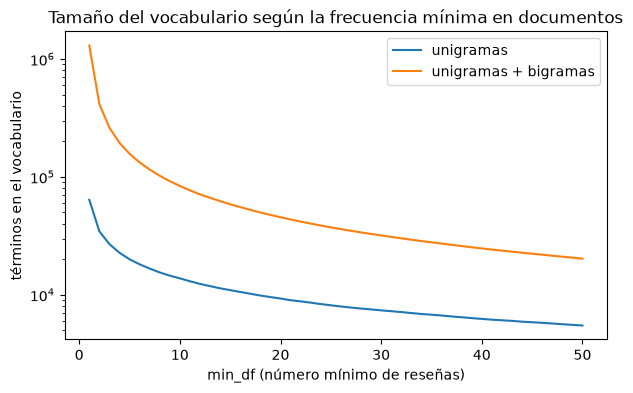

In [6]:
fig, ax = plt.subplots(figsize=(7, 4))
for ngram_range, label in [((1, 1), "unigramas"), ((1, 2), "unigramas + bigramas")]:
    presence = CountVectorizer(ngram_range=ngram_range, binary=True).fit_transform(reviews["clean"])
    doc_freq = np.asarray(presence.sum(axis=0)).ravel()   # documentos en los que aparece cada término
    min_dfs = np.arange(1, 51)
    ax.plot(min_dfs, [(doc_freq >= k).sum() for k in min_dfs], label=label)
    print(f"{label}: {len(doc_freq):,} términos con min_df=1 · {(doc_freq >= 2).sum():,} con min_df=2 · {(doc_freq >= 10).sum():,} con min_df=10")
ax.set_yscale("log")
ax.set(title="Tamaño del vocabulario según la frecuencia mínima en documentos",
       xlabel="min_df (número mínimo de reseñas)", ylabel="términos en el vocabulario")
ax.legend()
plt.show()

Exigir que un término aparezca en solo 2 reseñas ya elimina casi la mitad del vocabulario de unigramas (de 63 965 a 34 564 términos) y más de dos tercios del de unigramas y bigramas (de 1,3 millones a 415 544); a partir de ahí la curva baja más despacio. Es la forma más barata de reducir la dimensión sin perder casi información.

### 3.3. Qué términos destaca TF-IDF

Usamos a partir de aquí `min_df=5` y `max_df=0.5`, sin quitar palabras vacías. Primero, los términos con menor y mayor idf; después, para una reseña, los términos con más peso según el recuento y según TF-IDF.

In [7]:
vectorizer = TfidfVectorizer(min_df=5, max_df=0.5)
X = vectorizer.fit_transform(reviews["clean"])
vocab = vectorizer.get_feature_names_out()
idf_values = pd.Series(vectorizer.idf_, index=vocab).sort_values()
print("Menor idf:", ", ".join(f"{t} ({v:.2f})" for t, v in idf_values.head(8).items()))
print("Mayor idf:", ", ".join(f"{t} ({v:.2f})" for t, v in idf_values.tail(8).items()))

Menor idf: on (1.71), they (1.72), not (1.72), have (1.78), you (1.80), had (1.86), at (1.86), so (1.89)
Mayor idf: sprinkler (10.03), spouting (10.03), sportsbar (10.03), 1960s (10.03), 1130pm (10.03), 1950s (10.03), zuppa (10.03), 169 (10.03)


In [8]:
doc_id = reviews.index[reviews["clean"].str.contains("crusty fork")][0]       # una reseña de un restaurante asiático
print(f"[{reviews.loc[doc_id, 'stars']} estrellas] {reviews.loc[doc_id, 'clean']}\n")

doc_counts = CountVectorizer(vocabulary=vocab).fit_transform([reviews.loc[doc_id, "clean"]]).toarray().ravel()
doc_tfidf = X[doc_id].toarray().ravel()
pd.DataFrame({
    "recuento": [f"{vocab[i]} ({doc_counts[i]})" for i in doc_counts.argsort()[::-1][:8]],
    "TF-IDF": [f"{vocab[i]} ({doc_tfidf[i]:.2f})" for i in doc_tfidf.argsort()[::-1][:8]],
}, index=range(1, 9))

[1 estrellas] Blek! Not only did the server take 15+ minutes to take our order, I had a crusty fork, and the salt shaker on our table had a dried noodle attached to it. I've had way better Asian food, and worked in Irvine, CA for ten years, so my standards are high, admittedly. My Ma Po Tofu tasted like it came out of a can. My friend's veggie Pho had bland soup base, and canned mushrooms, that's a killer for me right there. If you want really good Pho, go to Tram's or Pho Mihn on Penn in Lawrenceville. For suburb sushi, try Chaya in Sq. Hill. And for good Korean, go to Sushi Kim's in the Strip. In fact, I think any Asian place in Pittsburgh, would be better than going here. Or just save a few bucks, and get a package of Ramen at the grocery store and add an egg to it. Even that's better than the so called noodles at Lu Lu's!



,recuento,TF-IDF
1,had (4),pho (0.32)
2,pho (3),asian (0.19)
3,better (3),chaya (0.18)
4,at (2),irvine (0.17)
5,go (2),lawrenceville (0.16)
6,on (2),better (0.16)
7,good (2),sushi (0.16)
8,or (2),shaker (0.15)


- Con `max_df=0.5` ya no están *the* ni *and*: los términos con menor idf son palabras gramaticales que aparecen en algo menos de la mitad de las reseñas, con idf cercano a $\ln 2 + 1 \approx 1{,}69$. Los de mayor idf aparecen en exactamente 5 reseñas (el mínimo): todos tienen el mismo idf.
- En la reseña, los recuentos ponen arriba las palabras gramaticales repetidas (*had*, *at*, *on*); TF-IDF pone arriba las que la describen: el plato (*pho*), el tipo de cocina (*asian*) y los restaurantes y ciudades con los que se compara, aunque aparezcan una sola vez. Esa es la propiedad que se aprovecha para buscar y clasificar.

### 3.4. Similitud del coseno: buscar reseñas parecidas

Con las reseñas como vectores TF-IDF normalizados, buscar es multiplicar la consulta por la matriz. Comparamos la búsqueda con TF-IDF y con recuentos, y medimos la similitud media entre reseñas tomadas al azar.

In [9]:
query = "spicy ramen noodle soup with a rich pork broth"
q_vec = vectorizer.transform([query])
scores = cosine_similarity(q_vec, X).ravel()
for i in scores.argsort()[::-1][:3]:
    print(f"{scores[i]:.3f} [{reviews.loc[i, 'stars']}★] {reviews.loc[i, 'clean'][:150]}...")

0.475 [3★] The place is always full of people so I was really looking forward to trying out their ramen. Ramen-Ya is also referred as Kurobuta Izakaya. Kurobuta ...
0.452 [2★] I really don't know what the hype is for this ramen place. This is my second time here because I thought I would give this place another try. Perhaps ...
0.446 [3★] We ordered ramen with pork and the pork was just too fatty. I didn't understand why they chose pork belly. The broth was okay, wasn't awesome and wasn...


In [10]:
count_vectorizer = CountVectorizer(min_df=5)               # recuentos, sin max_df ni normalización TF-IDF
C = count_vectorizer.fit_transform(reviews["clean"])

rng = np.random.default_rng(42)
pairs = rng.choice(len(reviews), size=(2_000, 2))          # 2 000 pares de reseñas al azar
pairs = pairs[pairs[:, 0] != pairs[:, 1]]

def mean_pair_similarity(M):
    a, b = M[pairs[:, 0]], M[pairs[:, 1]]
    return np.asarray(cosine_similarity(a, b).diagonal()).mean()

print(f"Similitud media entre reseñas al azar, recuentos: {mean_pair_similarity(C):.2f}")
print(f"Similitud media entre reseñas al azar, TF-IDF:    {mean_pair_similarity(X):.2f}")

toy_X = tfidf_vec.transform(toy)
print("\nCoseno entre las reseñas del ejemplo de la sección 3.1 (TF-IDF):")
pd.DataFrame(cosine_similarity(toy_X), index=[f"d{i + 1}" for i in range(4)],
             columns=[f"d{i + 1}" for i in range(4)]).round(2)

Similitud media entre reseñas al azar, recuentos: 0.35
Similitud media entre reseñas al azar, TF-IDF:    0.04

Coseno entre las reseñas del ejemplo de la sección 3.1 (TF-IDF):


,d1,d2,d3,d4
d1,1.00,0.60,0.37,0.45
d2,0.60,1.00,0.00,0.52
d3,0.37,0.00,1.00,0.17
d4,0.45,0.52,0.17,1.00


- La búsqueda devuelve tres reseñas de restaurantes de ramen (una de ellas habla del cerdo y del caldo), aunque la consulta es corta y comparte pocas palabras con cada reseña. Tienen 2 o 3 estrellas: la similitud del coseno mide de qué se habla, no la opinión.
- Con recuentos, dos reseñas cualesquiera tienen una similitud media de 0,35 solo por compartir *the*, *and*, *I* o *was*. TF-IDF baja esa similitud de fondo a 0,04: el parecido que queda viene de las palabras de contenido, y por eso los vecinos más cercanos tienen sentido.
- En el ejemplo pequeño, `d2` (*The pizza was cold*) se parece sobre todo a `d1` (0,60, comparten *the pizza was*) y a `d4` (0,52, comparten *the … was cold*), y nada a `d3`, con la que no comparte ningún término. `d3` y `d4` solo comparten *coffee* y se quedan en 0,17.

## 4. Parámetros importantes y errores comunes

| Parámetro | Qué controla | Valores típicos / consejo |
|---|---|---|
| `min_df` | Frecuencia mínima en documentos (número o proporción) | 2–5 en corpus de miles de documentos; elimina errores de escritura y nombres sueltos |
| `max_df` | Frecuencia máxima en documentos | 0,5–0,95 para quitar las palabras presentes en casi todos los documentos sin depender de una lista |
| `max_features` | Tamaño máximo del vocabulario (los términos más frecuentes) | Mejor `min_df`; si se usa, ojo: elige por frecuencia, no por utilidad |
| `ngram_range` | Longitud de los n-gramas | `(1, 2)` suele mejorar la clasificación (captura *not good*); multiplica el vocabulario |
| `stop_words` | Lista de palabras descartadas | `None` para sentimientos (la lista quita las negaciones); `"english"` o una lista propia para buscar o agrupar |
| `sublinear_tf` | Usa $1 + \ln \operatorname{tf}$ en lugar del recuento | `True` en documentos largos o con repeticiones |
| `token_pattern`, `tokenizer`, `lowercase` | Cómo se cortan y normalizan los *tokens* | El patrón por defecto descarta las palabras de una letra y parte *don't* en `don` + `t` |
| `norm`, `smooth_idf`, `use_idf` | Normalización y fórmula del idf | Los valores por defecto (`"l2"`, `True`, `True`) funcionan bien |

**Errores comunes y lecciones aprendidas**

- **Ajustar el vectorizador antes de separar entrenamiento y prueba.** En un análisis propio de reseñas de Yelp, el `TfidfVectorizer` se ajustó a todo el corpus (vocabulario y valores de idf) y después se separaron entrenamiento y prueba. Así el vocabulario y los pesos dependen de los documentos de prueba, una **fuga de información** (*data leakage*): en la demo de abajo, con los mismos ajustes, 5 de los 1 000 términos solo entran en el vocabulario gracias a ellos, y todos los valores de idf cambian. El efecto en la exactitud suele ser pequeño, pero la evaluación deja de ser honesta. Separa primero y ajusta el vectorizador solo con el entrenamiento, mejor dentro de un `Pipeline` (ver [clasificación de texto](06-clasificacion-de-texto.ipynb)).
- **Convertir la matriz dispersa en densa.** En ese mismo análisis, la matriz TF-IDF se pasó a densa con `.toarray()` antes de entrenar. Con `max_features=1000` cabía en memoria, pero con el vocabulario completo de este corpus serían 25,6 GB en lugar de 50 MB (sección 3.2). Los modelos lineales de scikit-learn, `cosine_similarity` y casi todo lo demás aceptan matrices dispersas; usa `.toarray()` solo para mirar unas pocas filas.
- **Quitar las negaciones con las palabras vacías.** En el mismo análisis, el vectorizador usaba la lista de NLTK, que incluye *not*, *no* y *nor*: *the food was good* y *the food was not good* acaban siendo el mismo vector (demo abajo). Para opiniones, no quites palabras vacías o quita las negaciones de la lista, y añade bigramas.
- **Limitar el vocabulario con `max_features` en lugar de `min_df`.** `max_features=1000` se queda con las 1 000 palabras más frecuentes, que en reseñas son sobre todo genéricas; un término raro pero muy informativo (*cockroach*, *food poisoning*) se pierde. `min_df` quita lo que es ruido sin recortar lo informativo.
- **Comparar documentos con recuentos sin normalizar.** Las palabras gramaticales dominan el producto escalar y la longitud de los documentos también: con recuentos, dos reseñas al azar tienen una similitud media de 0,35, frente a 0,04 con TF-IDF (sección 3.4).

In [11]:
# Fuga de información: ajustar el vectorizador con todo el corpus o solo con el entrenamiento
train_docs, test_docs = train_test_split(reviews["clean"], test_size=0.2, random_state=42)
params = {"max_features": 1_000, "min_df": 2, "max_df": 0.9}          # ajustes del análisis original
vocab_all = set(TfidfVectorizer(**params).fit(reviews["clean"]).get_feature_names_out())
vocab_train = set(TfidfVectorizer(**params).fit(train_docs).get_feature_names_out())
leaked = vocab_all - vocab_train
print(f"Términos que solo entran en el vocabulario por los documentos de prueba: {len(leaked)} de {len(vocab_all)}")
print("Ejemplos:", sorted(leaked)[:8])

# Las negaciones están en la lista de palabras vacías de NLTK
nltk_vectorizer = TfidfVectorizer(stop_words=stopwords.words("english")).fit(reviews["clean"].head(1_000))
pair = nltk_vectorizer.transform(["the food was good", "the food was not good"])
print("\n'not' en la lista de NLTK:", "not" in stopwords.words("english"))
print(f"Coseno entre 'the food was good' y 'the food was not good': {cosine_similarity(pair)[0, 1]:.2f}")

Términos que solo entran en el vocabulario por los documentos de prueba: 5 de 1000
Ejemplos: ['baked', 'bottom', 'mistake', 'none', 'solid']

'not' en la lista de NLTK: True
Coseno entre 'the food was good' y 'the food was not good': 1.00


## 5. Comparación con métodos relacionados

| Representación | Qué captura | Ventajas | Inconvenientes | Cuándo usarla |
|---|---|---|---|---|
| Bolsa de palabras (recuentos o binaria) | Qué palabras aparecen | Simple, interpretable | Dominada por palabras frecuentes; sin orden ni sinónimos | Naive Bayes, documentos cortos, línea base |
| TF-IDF | Palabras frecuentes en el documento y raras en el corpus | Rápida, interpretable, muy buena con modelos lineales | Dispersa y de alta dimensión; *tasty* y *delicious* son ortogonales | [Clasificación](06-clasificacion-de-texto.ipynb), búsqueda, agrupamiento con pocos datos |
| BM25 | Como TF-IDF, con saturación del tf y normalización por longitud | Estándar en motores de búsqueda | No viene en scikit-learn | Recuperación de información |
| `HashingVectorizer` | Recuentos en un espacio de tamaño fijo (función *hash*) | Sin vocabulario en memoria; sirve para flujos de datos | No se puede volver del índice a la palabra; colisiones | Corpus enormes o en *streaming* |
| LSA (TF-IDF + `TruncatedSVD`) | Combinaciones de términos que aparecen juntos | Densa y de baja dimensión; agrupa sinónimos parcialmente | Componentes difíciles de interpretar | Reducir dimensión antes de agrupar o visualizar |
| [Embeddings](04-embeddings-de-palabras.ipynb) (promedio de Word2Vec, *sentence embeddings*) | Significado aproximado | Densos; documentos con sinónimos quedan cerca | Pierden detalle léxico; necesitan modelos preentrenados o muchos datos | Similitud semántica, pocos datos etiquetados con [modelos preentrenados](10-modelos-de-lenguaje-preentrenados.ipynb) |

## 6. Referencias

### Fuentes

- Zhang, X., Zhao, J. y LeCun, Y. (2015). «Character-level convolutional networks for text classification». *Advances in Neural Information Processing Systems 28 (NIPS 2015)*, 649–657. Origen de Yelp Review Full, descargado de Hugging Face ([`Yelp/yelp_review_full`](https://huggingface.co/datasets/Yelp/yelp_review_full)) con [`datasets.load_dataset`](https://huggingface.co/docs/datasets/loading).
- scikit-learn: [Text feature extraction](https://scikit-learn.org/stable/modules/feature_extraction.html#text-feature-extraction) (bolsa de palabras, fórmula de TF-IDF, *hashing*), [`CountVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.CountVectorizer.html), [`TfidfVectorizer`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html) y [`cosine_similarity`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.cosine_similarity.html).
- NLTK: [corpus de palabras vacías](https://www.nltk.org/nltk_data/).

### Para saber más

- Manning, C. D., Raghavan, P. y Schütze, H. (2008). [*Introduction to Information Retrieval*](https://nlp.stanford.edu/IR-book/). Cambridge University Press. El capítulo 6 (*Scoring, term weighting and the vector space model*) desarrolla tf, idf, sus variantes y la similitud del coseno; el 11, el modelo probabilístico del que sale BM25.
- Salton, G. y Buckley, C. (1988). «Term-weighting approaches in automatic text retrieval». *Information Processing & Management*, 24(5), 513–523. El artículo clásico que comparó sistemáticamente las variantes de ponderación tf-idf y la normalización por longitud.